# IBM HR: Employee Attrition Analysis
---
### Project Overview
 
- **Dataset**: IBM HR Analytics Employee Attrition Dataset: 1,470 records, 35 columns
- **Source**: [Kaggle: IBM HR Dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
- **Objective**: To Identify the key drivers of employee attrition and build a data-backed retention strategy.
 ---
### Aspects of Analysis:
 
- **Category A** - Employees profile: department, job role, age & gender.
- **Category B** - Compensation & workload: income, overtime & salary hike.
- **Category C** - Employee Satisfaction & Working environment: job/environment/relationship satisfaction, work-life balance & distance from home.
- **Category D** - Career & tenure: years at company, Previous companies, promotion& education Level.
---
### Tech Stack:
 
- `pandas`: Data Manipulation and Aggregation
- `matplotlib` / `seaborn`:  Visualizations
- `numpy`: Satistical Operations
 ---
### Key Question:
 
 > *Which employees are most likely to leave and what can be the actions for their retention*
---

## 1. Data Loading & Preprocessing

In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch
import matplotlib.colors as mcolors

df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

In [61]:
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. KPIs Headline

### 2.1. Data Aggregation

In [63]:
df['Attrition_num'] = df['Attrition'].map({'Yes' : 1, 'No' : 0})

Leavers = df[df['Attrition'] == 'Yes']
Stayers = df[df['Attrition'] == 'No']

# Attrition Count & Percentage Calculation
attrition_count = df['Attrition_num'].sum()
attrition_per = (attrition_count / len(df)) * 100
total_emp = df.shape[0]

# Average Monthly Income overall and specific for Leavers
overall_avg_income = df['MonthlyIncome'].mean()
attrition_avg_income = Leavers['MonthlyIncome'].mean()

# Overall Overtime Employees & Leavers among them
ot_overall_per = ((df['OverTime'] == 'Yes').sum() / len(df)) * 100
ot_leavers_per = ((Leavers['OverTime'] == 'Yes').sum() / (df['OverTime'] == 'Yes').sum()) * 100

# Average tenure of Leavers & Stayers
avg_tenure_leavers = Leavers['YearsAtCompany'].mean()
avg_tenure_stayers = Stayers['YearsAtCompany'].mean()

---
#### Attrition rate here is calculated as leavers divided by total headcount, as the dataset does not contain period-wise hiring/exit records required for the standard Attrition rate formula.
---

### 2.2. Plotting Headline KPIs

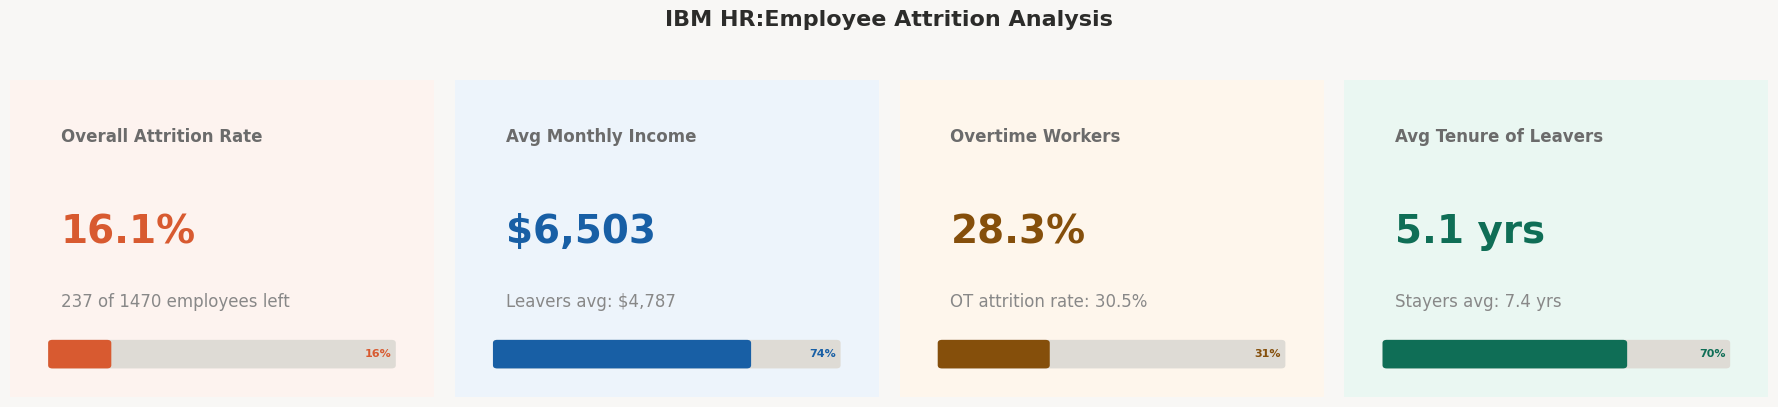

In [64]:
kpis = [
    {
        "title":    "Overall Attrition Rate",
        "value":    f"{attrition_per:.1f}%",
        "subtitle": f"{int(attrition_count)} of {total_emp} employees left",
        "color":    "#D85A30",
        "bg":       "#FDF3EF",
        "bar_pct":  attrition_per / 100,
    },
    {
        "title":    "Avg Monthly Income",
        "value":    f"${overall_avg_income:,.0f}",
        "subtitle": f"Leavers avg: ${attrition_avg_income:,.0f}",
        "color":    "#185FA5",
        "bg":       "#EDF4FB",
        "bar_pct":  attrition_avg_income / overall_avg_income,
    },
    {
        "title":    "Overtime Workers",
        "value":    f"{ot_overall_per:.1f}%",
        "subtitle": f"OT attrition rate: {ot_leavers_per:.1f}%",
        "color":    "#854F0B",
        "bg":       "#FEF6EC",
        "bar_pct":  ot_leavers_per / 100,
    },
    {
        "title":    "Avg Tenure of Leavers",
        "value":    f"{avg_tenure_leavers:.1f} yrs",
        "subtitle": f"Stayers avg: {avg_tenure_stayers:.1f} yrs",
        "color":    "#0F6E56",
        "bg":       "#EAF7F2",
        "bar_pct":  avg_tenure_leavers / avg_tenure_stayers,
    },
]
 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#F8F7F5')
 
for ax, kpi in zip(axes, kpis):
 
    ax.set_facecolor(kpi["bg"])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
 
    ax.text(
        0.12, 0.82, kpi["title"],
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        color='#6B6B6B',
        va='center'
    )
 
    ax.text(
        0.12, 0.52, kpi["value"],
        transform=ax.transAxes,
        fontsize=28, fontweight='bold',
        color=kpi["color"],
        va='center'
    )
 
    ax.text(
        0.12, 0.30, kpi["subtitle"],
        transform=ax.transAxes,
        fontsize=12,
        color='#888888',
        va='center'
    )
 
    bar_bg = ax.add_patch(FancyBboxPatch(
        (0.10, 0.10), 0.80, 0.07,
        boxstyle="round,pad=0.01",
        linewidth=0,
        facecolor='#DEDBD5',
        transform=ax.transAxes,
        zorder=2
    ))
 
    fill_width = 0.80 * min(kpi["bar_pct"], 1.0)
    ax.add_patch(FancyBboxPatch(
        (0.10, 0.10), fill_width, 0.07,
        boxstyle="round,pad=0.01",
        linewidth=0,
        facecolor=kpi["color"],
        transform=ax.transAxes,
        zorder=3
    ))
 
    ax.text(
        0.90, 0.135,
        f"{kpi['bar_pct']*100:.0f}%",
        transform=ax.transAxes,
        fontsize=8,
        color=kpi["color"],
        fontweight='bold',
        va='center',
        ha='right'
    )
 
plt.suptitle(
    "IBM HR:Employee Attrition Analysis",
    fontsize=16, fontweight='bold',
    color='#2C2C2A', y=1.02
)
 
plt.tight_layout(pad=1.5)
plt.savefig("hr_kpi_headlines.png", dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

### 2.3. Correlation Heatmap

In [65]:
corr = df.corr(numeric_only = True)

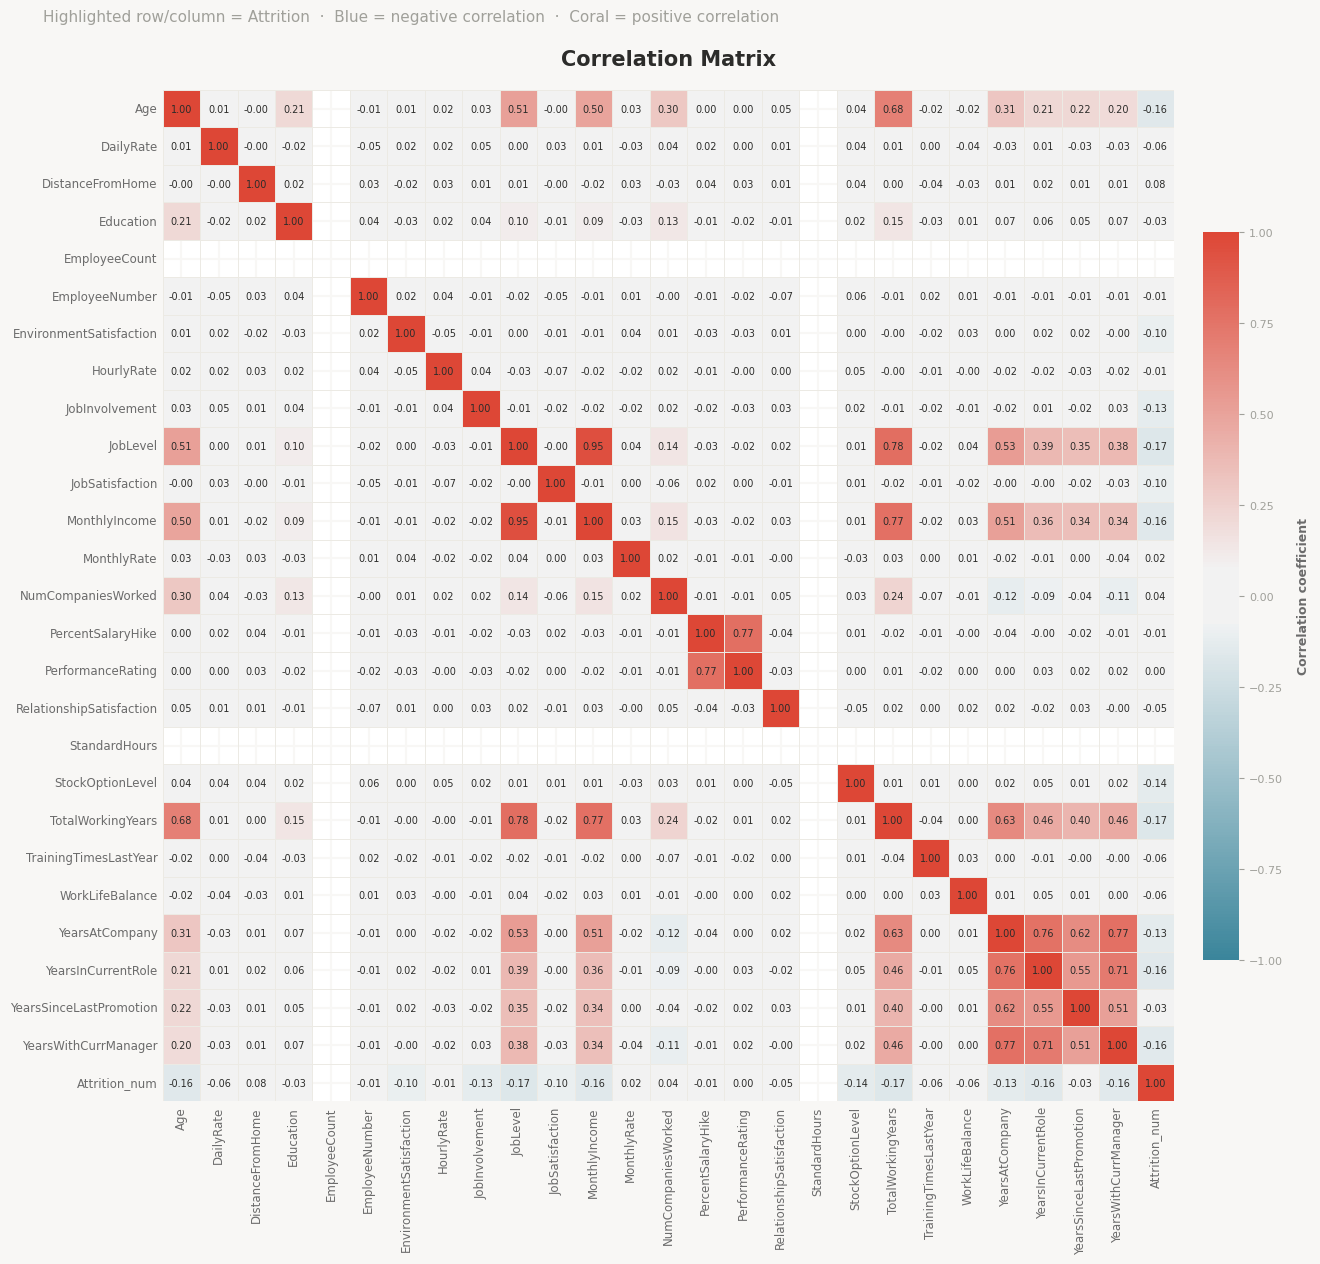

In [66]:
# Standardizing Color Pallete
BG_PAGE      = '#F8F7F5'  
BG_CARD      = '#FFFFFF'   
COLOR_TITLE  = '#2C2C2A'  
COLOR_LABEL  = '#6B6B6B'  
COLOR_MUTED  = '#A0A09A'  
COLOR_ACCENT = '#D85A30'  
COLOR_NEG    = '#185FA5' 
FONT_FAMILY  = 'DejaVu Sans'
COLOR_NEUTRAL='#B4B2A9'
FONT  = 'DejaVu Sans'
COLOR_STAY   = '#185FA5'
COLOR_WARN   = '#EF9F27'


# Setting up the Figure
fig, ax = plt.subplots(figsize=(16, 13))
fig.patch.set_facecolor(BG_PAGE)
ax.set_facecolor(BG_CARD)
 
# Plotting Heatmap
cmap = sns.diverging_palette(
    h_neg=220, h_pos=15,
    s=80, l=52, sep=20,
    as_cmap=True
)
 
sns.heatmap(
    corr,
    ax=ax,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7, 'color': COLOR_TITLE, 'fontfamily': FONT_FAMILY},
    linewidths=0.4,
    linecolor='#ECEAE4',
    square=True,
    cbar_kws={'shrink': 0.72, 'pad': 0.02}
)
 
# Graph Customization
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8, colors=COLOR_MUTED)
cbar.outline.set_edgecolor('#ECEAE4')
cbar.set_label('Correlation coefficient', fontsize=9,
               color=COLOR_LABEL, labelpad=10)
 
# Axis Labelling
ax.tick_params(axis='x', labelsize=8.5, colors=COLOR_LABEL,
               rotation=90, length=0)
ax.tick_params(axis='y', labelsize=8.5, colors=COLOR_LABEL,
               rotation=0,  length=0)
 
x_labels = [t.get_text() for t in ax.get_xticklabels()]
y_labels = [t.get_text() for t in ax.get_yticklabels()]
 
for tick in ax.get_xticklabels():
    if tick.get_text() == 'Attrition':
        tick.set_color(COLOR_ACCENT)
        tick.set_fontweight('bold')
 
for tick in ax.get_yticklabels():
    if tick.get_text() == 'Attrition':
        tick.set_color(COLOR_ACCENT)
        tick.set_fontweight('bold')
 
# Setting Titles
ax.set_title(
    'Correlation Matrix',
    fontsize=15, fontweight='bold',
    color=COLOR_TITLE, pad=18,
    fontfamily=FONT_FAMILY
)
fig.text(
    0.13, 0.96,
    'Highlighted row/column = Attrition  ·  Blue = negative correlation  ·  Coral = positive correlation',
    fontsize=11, color=COLOR_MUTED, fontfamily=FONT_FAMILY
)
 
for spine in ax.spines.values():
    spine.set_edgecolor('#ECEAE4')
    spine.set_linewidth(0.8)
 
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
#### Key Insights
 
- `NumCompaniesWorked`, and `DistanceFromHome` show **positive correlation** with attrition: More of these = more likely to leave
- `MonthlyIncome`, `JobLevel`, `TotalWorkingYears`, and `Age` show **negative correlation** : higher values = more likely to stay
- `DailyRate`, `HourlyRate`, and `MonthlyRate` show **near-zero correlation**: not meaningful predictors
- `YearsAtCompany`, `YearsInCurrentRole`, and `TotalWorkingYears` are highly correlated with each other : expected, as tenure metrics move together
---

## 3. Employees Profile Analysis

### 3.1. What is the attrition rate across departments?

In [67]:
dept_attrition = df.groupby(by = 'Department')['Attrition_num'].sum()
dept_total = df.groupby(by = 'Department')['Attrition_num'].count()
dept_attrition_rate = (dept_attrition / dept_total * 100).sort_values(ascending = False)

In [68]:
# Standardizing Color Pallete
BG_PAGE      = '#F8F7F5'  
BG_CARD      = '#FFFFFF'   
COLOR_TITLE  = '#2C2C2A'  
COLOR_LABEL  = '#6B6B6B'  
COLOR_MUTED  = '#A0A09A'  
COLOR_ACCENT = '#D85A30'  
COLOR_NEG    = '#185FA5' 
FONT_FAMILY  = 'DejaVu Sans'
COLOR_NEUTRAL= '#B4B2A9'

# Setting Global Plotting Style
def apply_custom_theme():
    sns.set_style("white") 
    plt.rcParams.update({
        "figure.facecolor": BG_PAGE,
        "axes.facecolor": BG_CARD,
        "axes.edgecolor": COLOR_MUTED,
        "axes.labelcolor": COLOR_LABEL,
        "axes.titlecolor": COLOR_TITLE,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.labelweight": "bold",
        "xtick.color": COLOR_LABEL,
        "ytick.color": COLOR_LABEL,
        "text.color": COLOR_LABEL,
        "font.family": FONT_FAMILY,
        "axes.grid": True,
        "grid.color": BG_PAGE, 
        "grid.linewidth": 1.5
    })

apply_custom_theme()

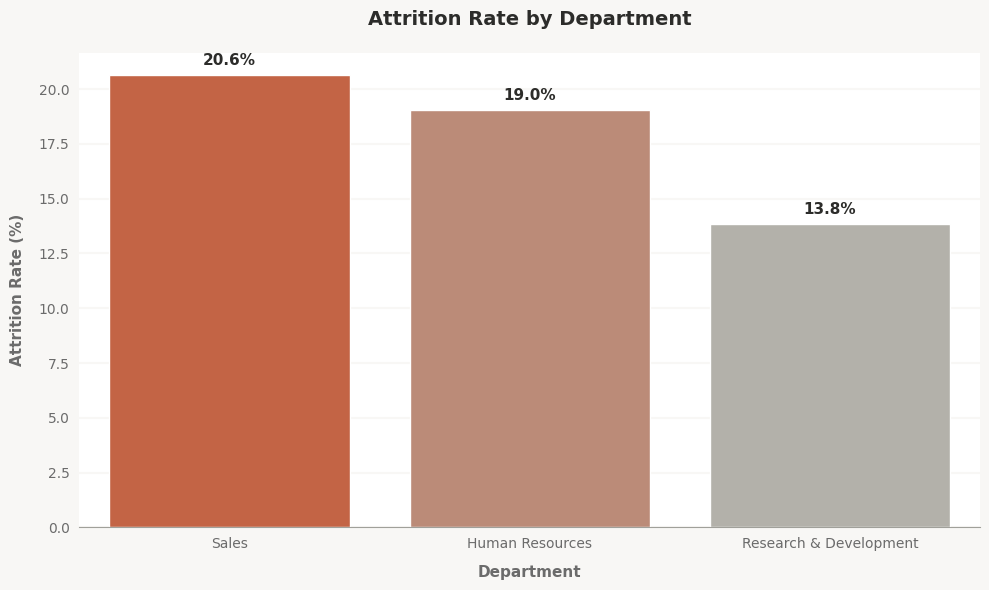

In [69]:
n_bars = len(dept_attrition_rate)
gradient_palette = sns.blend_palette([COLOR_ACCENT, COLOR_NEUTRAL], n_colors=n_bars)

# Plotting the Graph
fig, ax = plt.subplots(figsize=(10, 6))

# Graph Customization
sns.barplot(
    x=dept_attrition_rate.index, 
    y=dept_attrition_rate.values, 
    hue=dept_attrition_rate.index,
    palette=gradient_palette,
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Attrition Rate by Department', pad=20)
ax.set_xlabel('Department', labelpad=10)
ax.set_ylabel('Attrition Rate (%)', labelpad=10)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE,
                xytext=(0, 5), textcoords='offset points')

sns.despine(left=True, bottom=False) 
plt.tight_layout()
plt.show()

---
#### Key Insights
 
- **Sales** has the highest attrition rate (~21%), nearly double that of R&D
- **HR** department has the Significant Attrition rate of 19% despite being a smaller team
- No department is below 13%
---

### 3.2. Which job roles have the highest attrition?

In [70]:
job_attrition = df.groupby(by = 'JobRole')['Attrition_num'].sum()
job_total = df.groupby(by = 'JobRole')['Attrition_num'].count()
job_attrition_rate = (job_attrition / job_total * 100).sort_values(ascending = False)

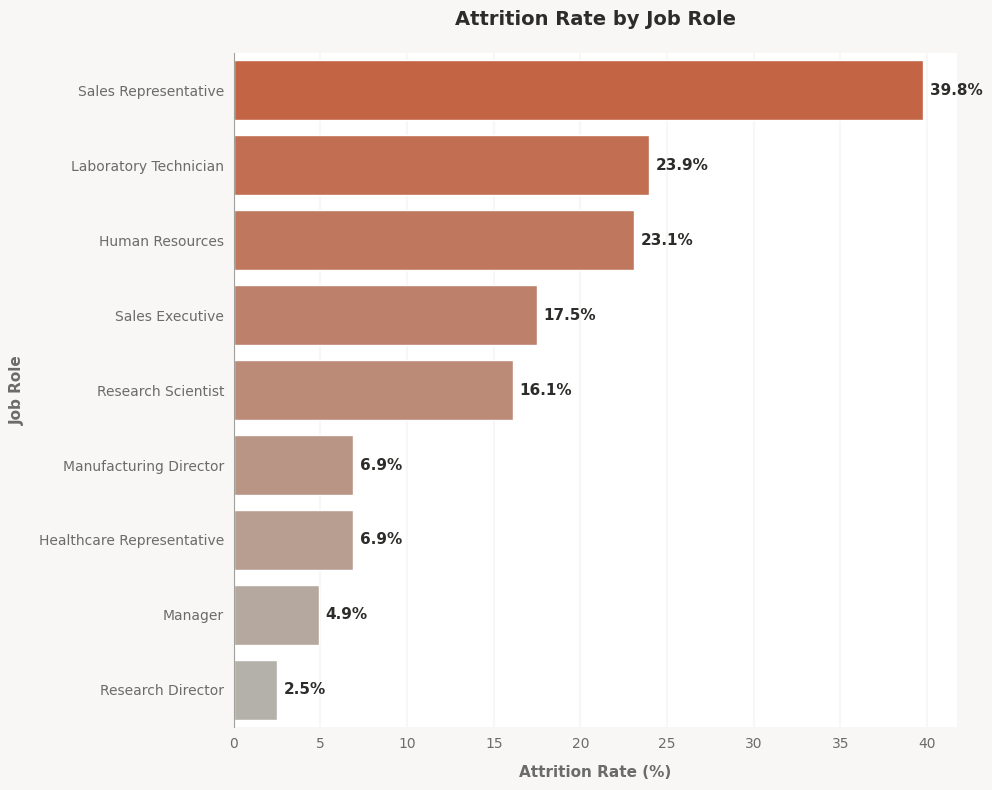

In [71]:
n_bars_job = len(job_attrition_rate)
gradient_palette_job = sns.blend_palette([COLOR_ACCENT, COLOR_NEUTRAL], n_colors=n_bars_job)

# Plotting the Graph
fig, ax = plt.subplots(figsize=(10, 8)) 

# Horizontal barplot
sns.barplot(
    x=job_attrition_rate.values, 
    y=job_attrition_rate.index, 
    hue=job_attrition_rate.index,
    palette=gradient_palette_job,
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Attrition Rate by Job Role', pad=20)
ax.set_xlabel('Attrition Rate (%)', labelpad=10)
ax.set_ylabel('Job Role', labelpad=10)

# Add data labels at the end of the horizontal bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE,
                xytext=(5, 0), textcoords='offset points')

sns.despine(left=False, bottom=True) 
plt.tight_layout()
plt.show()

---
#### Key Insights 
 
- **Sales Representatives** have ~40% attrition: highest of any role by a wide margin
- **Lab Technicians** (~ 24%) and **Human Resources** (~ 23%) are the next most at-risk roles
- Managers and Research Directors have near-zero attrition: **seniority strongly predicts retention**
---

### 3.3. How does attrition vary by age group?

In [72]:
age_bins = [18, 26, 36, 46, 56, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '55+']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Data Aggregation
age_attrition = df.groupby('AgeGroup', observed=True)['Attrition_num'].sum()
age_total = df.groupby('AgeGroup', observed=True)['Attrition_num'].count()
age_attrition_rate = (age_attrition / age_total * 100).fillna(0)

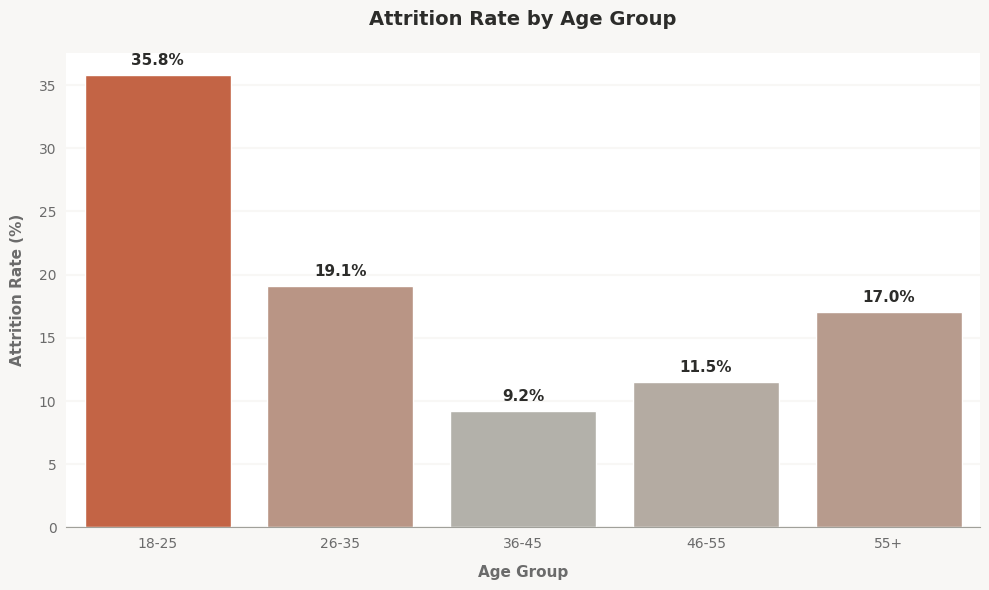

In [73]:
# --- 2. Plotting Q3 ---
fig, ax = plt.subplots(figsize=(10, 6))

# Create a custom colormap that maps values from Neutral to Accent
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(age_attrition_rate.min(), age_attrition_rate.max())
bar_colors = [cmap(norm(value)) for value in age_attrition_rate.values]

# Plot the bar chart keeping the natural age order
sns.barplot(
    x=age_attrition_rate.index, 
    y=age_attrition_rate.values, 
    palette=bar_colors,
    hue=age_attrition_rate.index,
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Attrition Rate by Age Group', pad=20)
ax.set_xlabel('Age Group', labelpad=10)
ax.set_ylabel('Attrition Rate (%)', labelpad=10)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE,
                xytext=(0, 5), textcoords='offset points')

# Clean up layout
sns.despine(left=True, bottom=False) 
plt.tight_layout()
plt.show()

---
#### Key Insights 
 
- The **18 - 25 age group** has the highest attrition rate (~36%): early career exploration phase.
- Attrition drops consistently with age the **36 - 45 group** is the most stable at under 10%.
- After 45 Attrition Rate again increases probably due to retirements.
---

### 3.4. Does gender affect attrition?

In [74]:
gender_attrition = df.groupby(by = 'Gender')['Attrition_num'].sum()
gender_total = df.groupby(by = 'Gender')['Attrition_num'].count()
gender_attrition_rate = (gender_attrition / gender_total * 100).sort_values(ascending = False)

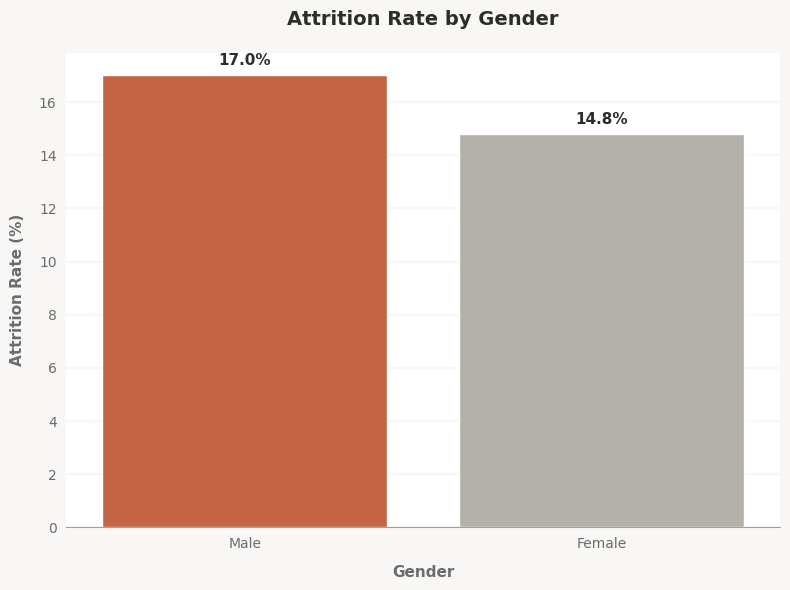

In [75]:
n_bars_gender = len(gender_attrition_rate)
gradient_palette_gender = sns.blend_palette([COLOR_ACCENT, COLOR_NEUTRAL], n_colors=n_bars_gender)

# Plotting Graphs
fig, ax = plt.subplots(figsize=(8, 6)) # Slightly narrower since there are fewer bars

# Plot the bar chart
sns.barplot(
    x=gender_attrition_rate.index, 
    y=gender_attrition_rate.values, 
    hue=gender_attrition_rate.index,
    palette=gradient_palette_gender,
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Attrition Rate by Gender', pad=20)
ax.set_xlabel('Gender', labelpad=10)
ax.set_ylabel('Attrition Rate (%)', labelpad=10)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE,
                xytext=(0, 5), textcoords='offset points')

sns.despine(left=True, bottom=False) 
plt.tight_layout()
plt.show()

---
#### Key Insights 
 
- Males leave at ~17%, females at ~15% only a **2% gap**
- Gender is **not a significant driver** of attrition in this dataset
---

## 4. Compensation & workload

### 4.1. How does monthly income differ between leavers and stayers?

In [76]:
income_bins   = [0, 3000, 6000, 9000, 12000, 20000]
income_labels = ['< 3k', '3k–6k', '6k–9k', '9k–12k', '12k+']

df['IncomeGroup'] = pd.cut(df['MonthlyIncome'], bins=income_bins, labels=income_labels, right=False)

# Calculate attrition rate per income Group
bin_attrition = df.groupby('IncomeGroup', observed=True)['Attrition_num'].sum()
bin_total = df.groupby('IncomeGroup', observed=True)['Attrition_num'].count()
bin_attrition_rate = (bin_attrition / bin_total * 100).fillna(0)

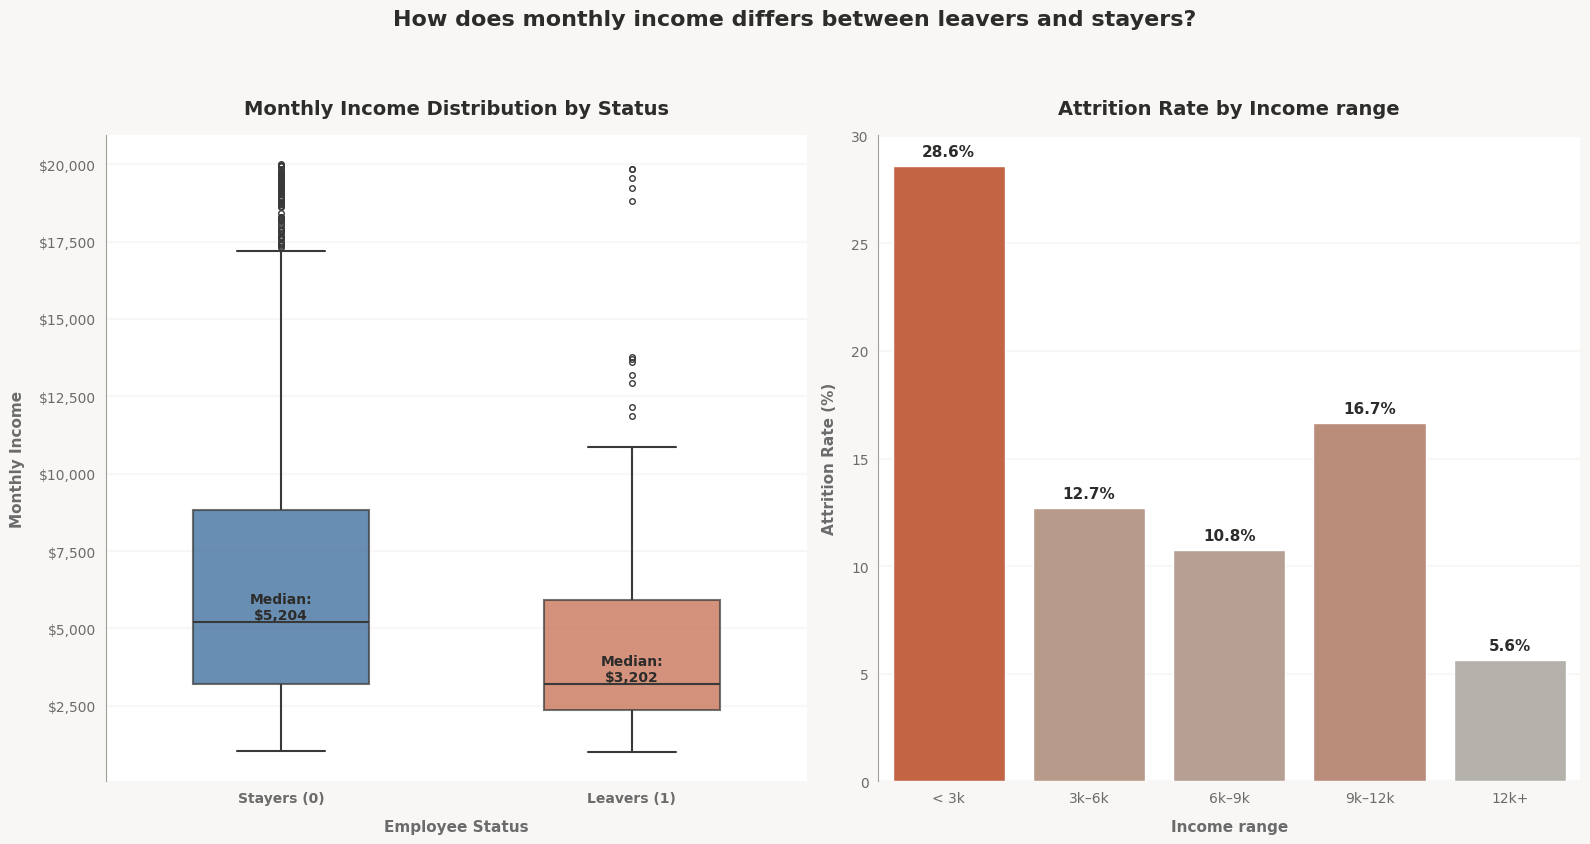

In [77]:
# Plotting Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Box Plot 
attrition_colors = {0: COLOR_NEG, 1: COLOR_ACCENT} 

sns.boxplot(
    data=df, 
    x='Attrition_num', 
    y='MonthlyIncome', 
    palette=attrition_colors,
    hue='Attrition_num',
    legend=False,
    width=0.5,        
    linewidth=1.5,    
    fliersize=4,      
    boxprops={'alpha': 0.7},  
    ax=ax1
)

# Add median annotations to Plots
medians = df.groupby('Attrition_num')['MonthlyIncome'].median()
for xtick, median in medians.items():
    ax1.text(
        x=xtick, 
        y=median, 
        s=f'Median:\n${median:,.0f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        color=COLOR_TITLE,
        fontsize=10,
    )
    
# Graph Customization
ax1.set_title('Monthly Income Distribution by Status', pad=15)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Stayers (0)', 'Leavers (1)'], fontweight='bold')
ax1.set_xlabel('Employee Status', labelpad=10)
ax1.set_ylabel('Monthly Income', labelpad=10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Plotting Bar Graph
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(bin_attrition_rate.min(), bin_attrition_rate.max())
bar_colors = [cmap(norm(value)) for value in bin_attrition_rate.values]

sns.barplot(
    x=bin_attrition_rate.index, 
    y=bin_attrition_rate.values, 
    palette=bar_colors,
    hue=bin_attrition_rate.index,
    legend=False,
    ax=ax2
)

# Add percentage annotations to Bars
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE,
                xytext=(0, 5), textcoords='offset points')

ax2.set_title('Attrition Rate by Income range', pad=15)
ax2.set_xlabel('Income range', labelpad=10)
ax2.set_ylabel('Attrition Rate (%)', labelpad=10)

# Layout setting
fig.suptitle('How does monthly income differs between leavers and stayers?', 
             fontsize=16, fontweight='bold', color=COLOR_TITLE, y=1.05)

sns.despine(left=False, bottom=True) 
plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Leavers **median income is significantly lower** than stayers across the board.
- Employees earning **'< 3k' per month** have the highest attrition rate (~ 29%).
- Attrition drops sharply in the **$6k–$9k range**: salary above a threshold acts as a strong retention lever.
---

### 4.2. Does overtime drive attrition?

In [78]:
ot_attrition_counts = df.groupby(['OverTime', 'Attrition_num']).size().unstack()
# Convert to percentages across the rows
ot_attrition_pct = ot_attrition_counts.div(ot_attrition_counts.sum(axis=1), axis=0) * 100

# Attrition Rate by Department and OverTime
dept_ot_group = df.groupby(['Department', 'OverTime'], observed=True)['Attrition_num']
dept_ot_rate = (dept_ot_group.sum() / dept_ot_group.count() * 100).reset_index(name='AttritionRate')

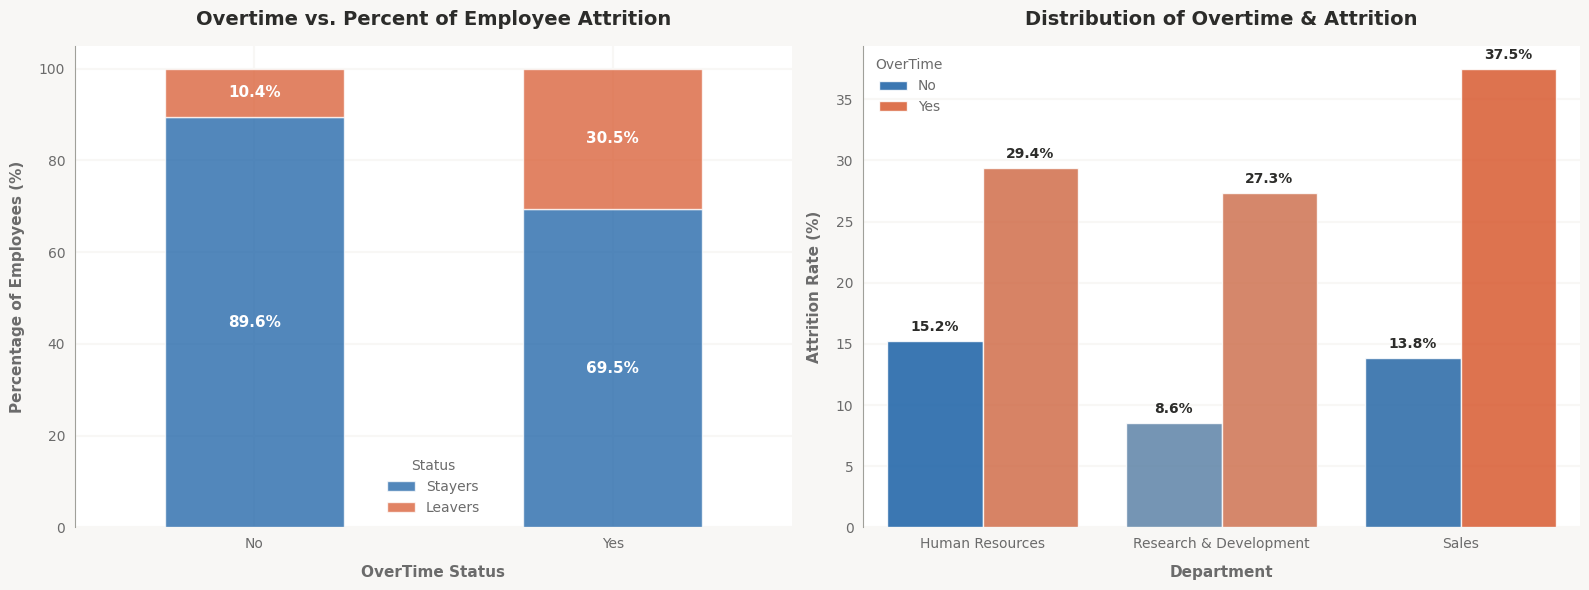

In [79]:
# Plotting the Subplots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked Bar Graph Plotting
ot_attrition_pct.plot(
    kind='bar', 
    stacked=True, 
    color=[COLOR_NEG, COLOR_ACCENT], 
    alpha=0.75, 
    ax=ax1
)

# Graph Customization
for c in ax1.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax1.bar_label(c, labels=labels, label_type='center', color=BG_CARD, fontweight='bold', fontsize=11)

ax1.set_title('Overtime vs. Percent of Employee Attrition', pad=15)
ax1.set_xlabel('OverTime Status', labelpad=10)
ax1.set_ylabel('Percentage of Employees (%)', labelpad=10)
ax1.legend(['Stayers', 'Leavers'], title='Status', frameon=False)
ax1.tick_params(axis='x', rotation=0) 


import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Plotting the 2nd graph
sns.barplot(
    data=dept_ot_rate, 
    x='Department', 
    y='AttritionRate', 
    hue='OverTime',
    palette={'No': '#dddddd', 'Yes': '#dddddd'},
    ax=ax2
)

# Defining Colour Gradient
cmap_no = mcolors.LinearSegmentedColormap.from_list("grad_no", [COLOR_NEUTRAL, COLOR_NEG])
cmap_yes = mcolors.LinearSegmentedColormap.from_list("grad_yes", [COLOR_NEUTRAL, COLOR_ACCENT])

max_no = dept_ot_rate[dept_ot_rate['OverTime'] == 'No']['AttritionRate'].max()
max_yes = dept_ot_rate[dept_ot_rate['OverTime'] == 'Yes']['AttritionRate'].max()

norm_no = plt.Normalize(0, max_no)
norm_yes = plt.Normalize(0, max_yes)

num_depts = len(dept_ot_rate['Department'].unique())

# Graph Customization
for i, p in enumerate(ax2.patches):
    height = p.get_height()
    if height > 0:
        if i < num_depts:
            p.set_facecolor(cmap_no(norm_no(height)))
        else:
            p.set_facecolor(cmap_yes(norm_yes(height)))
        
        p.set_alpha(0.85)
        
        # Annotation to top of each grouped bar
        ax2.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color=COLOR_TITLE,
                    xytext=(0, 5), textcoords='offset points')

ax2.set_title('Distribution of Overtime & Attrition', pad=15)
ax2.set_xlabel('Department', labelpad=10)
ax2.set_ylabel('Attrition Rate (%)', labelpad=10)

legend_elements = [
    Patch(facecolor=COLOR_NEG, alpha=0.85, label='No'),
    Patch(facecolor=COLOR_ACCENT, alpha=0.85, label='Yes')
]
ax2.legend(handles=legend_elements, title='OverTime', frameon=False)



sns.despine(left=False, bottom=True) 
plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Employees doing overtime leave at **30.5%** vs **10.4%** for non-OverTime employees: a **3x risk multiplier**
- This is the **single strongest predictor** of attrition in the entire dataset
- The overtime-attrition pattern holds across **all three departments**: it is not department specific
---

### 4.3. Does number of salary hikes affect attrition?

In [80]:
# Data Aggregation
hike_attrition = df.groupby('PercentSalaryHike', observed=True)['Attrition_num'].sum()
hike_total = df.groupby('PercentSalaryHike', observed=True)['Attrition_num'].count()
hike_attrition_rate = (hike_attrition / hike_total * 100).fillna(0)

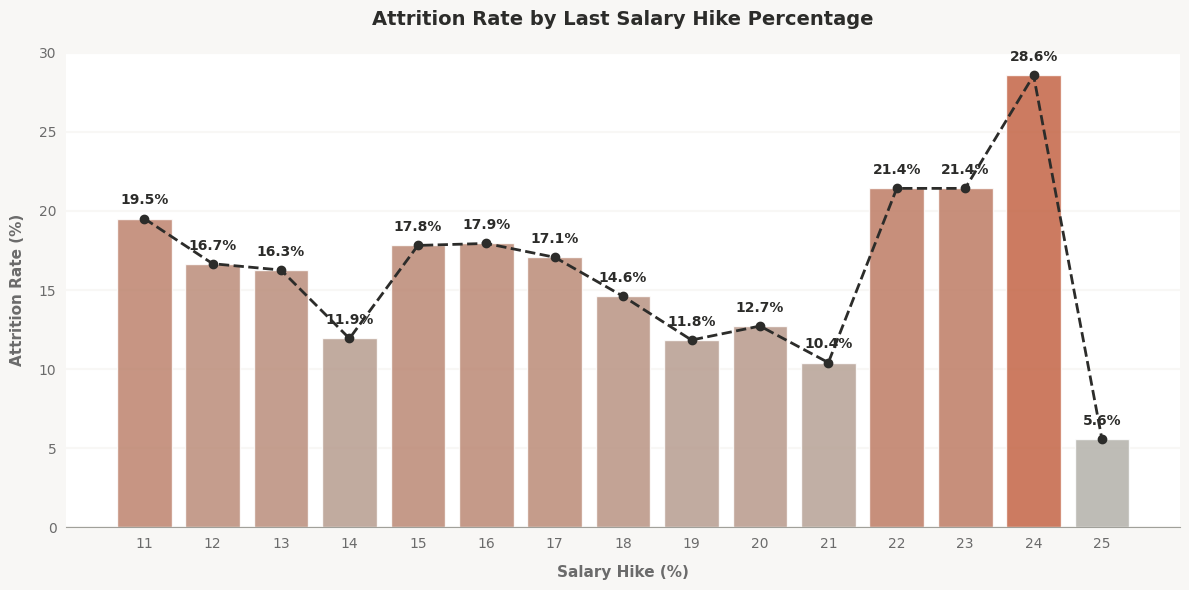

In [81]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Define the gradient mapping 
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(hike_attrition_rate.min(), hike_attrition_rate.max())
bar_colors = [cmap(norm(value)) for value in hike_attrition_rate.values]

# Draw the Bar Chart
sns.barplot(
    x=hike_attrition_rate.index, 
    y=hike_attrition_rate.values, 
    palette=bar_colors,
    hue=hike_attrition_rate.index,
    legend=False,
    ax=ax,
    alpha=0.85
)

# Overlay the Trend Line
ax.plot(
    range(len(hike_attrition_rate)), 
    hike_attrition_rate.values, 
    color=COLOR_TITLE, 
    marker='o', 
    linewidth=2, 
    markersize=6,
    linestyle='--'
)

# Add data labels slightly above the markers
for i, rate in enumerate(hike_attrition_rate.values):
    ax.annotate(f'{rate:.1f}%', 
                (i, rate), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color=COLOR_TITLE,
                xytext=(0, 8), textcoords='offset points')

# Add title and labels
ax.set_title('Attrition Rate by Last Salary Hike Percentage', pad=20)
ax.set_xlabel('Salary Hike (%)', labelpad=10)
ax.set_ylabel('Attrition Rate (%)', labelpad=10)


sns.despine(left=True, bottom=False) 
plt.tight_layout()
plt.show()

---
#### Key Insights 
 
- Employees receiving **lower hikes (11–13%)** leave at a higher rate than those receiving hikes upto 21%
- Employees with hikes greater than 21% are also prone to higher Attrition.
- The relationship is **not perfectly linear** some mid-hike employees also show elevated attrition.
- Hike % alone is a **weak standalone predictor** as the graph is not evenly distributed even higher hikes have higher attrition rates.
---

## 5. Employee Satisfaction & Work environment

### 5.1. How do satisfaction scores relates to attrition?

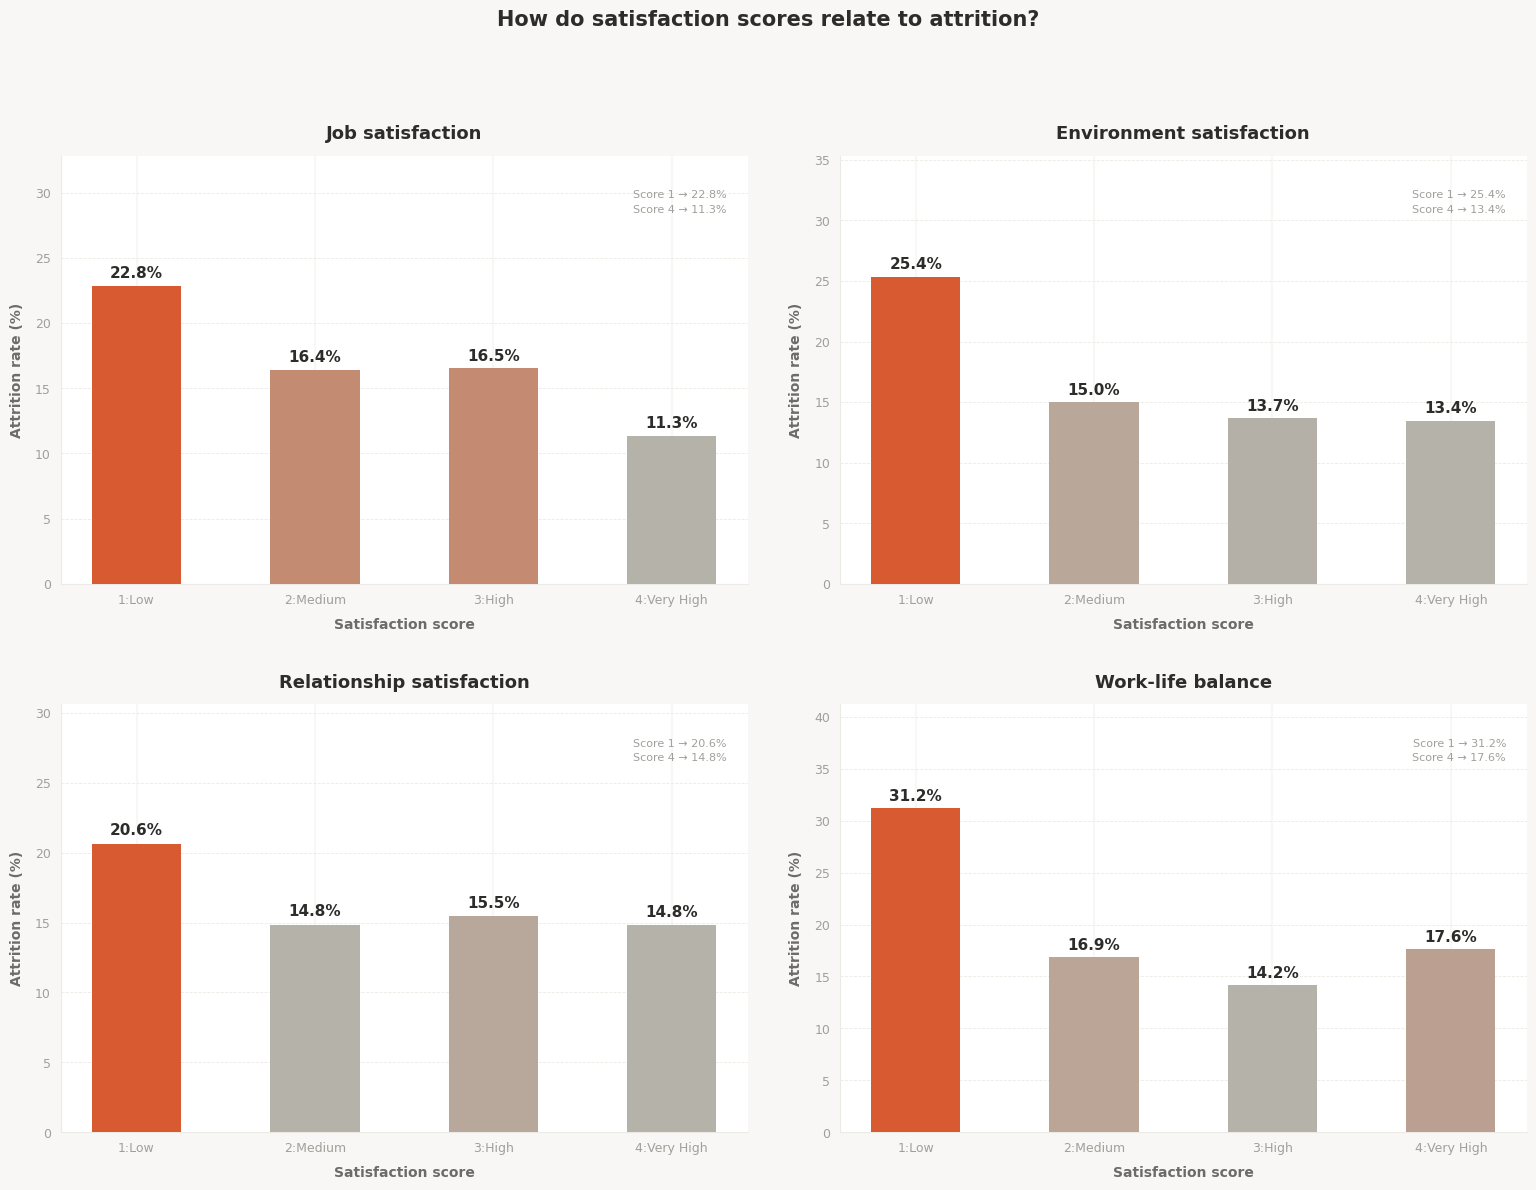

In [82]:
sat_cols = {
    'JobSatisfaction'          : 'Job satisfaction',
    'EnvironmentSatisfaction'  : 'Environment satisfaction',
    'RelationshipSatisfaction' : 'Relationship satisfaction',
    'WorkLifeBalance'          : 'Work-life balance',
}
score_labels = {1: '1:Low', 2: '2:Medium', 3: '3:High', 4: '4:Very High'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(BG_PAGE)
axes = axes.flatten()

# Defining Color Gradient 
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])

# Plotting the Graphs
for ax, (col, title) in zip(axes, sat_cols.items()):
    ax.set_facecolor(BG_CARD)

    rate = df.groupby(col).apply(
        lambda x: (x['Attrition'] == 'Yes').sum() / len(x) * 100, include_groups=False
    ).round(2)

    x_pos  = np.arange(len(rate))
    
    norm = plt.Normalize(rate.min(), rate.max())
    colors = [cmap(norm(v)) for v in rate.values]

    bars = ax.bar(x_pos, rate.values, color=colors,
                  width=0.5, zorder=3, edgecolor='none')

    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([score_labels[i] for i in rate.index], fontsize=9)
    ax.set_ylim(0, rate.max() + 10)
    ax.set_title(title, fontsize=13, fontweight='bold',
                 color=COLOR_TITLE, pad=12, fontfamily=FONT_FAMILY)
    ax.set_xlabel('Satisfaction score', fontsize=10, color=COLOR_LABEL, labelpad=8)
    ax.set_ylabel('Attrition rate (%)', fontsize=10, color=COLOR_LABEL, labelpad=8)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#ECEAE4')
    ax.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
    ax.set_axisbelow(True)

    low_rate  = rate[1]
    high_rate = rate[4]
    ax.text(0.97, 0.92,
            f'Score 1 → {low_rate:.1f}%\nScore 4 → {high_rate:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=COLOR_MUTED, fontfamily=FONT_FAMILY, linespacing=1.6)

plt.suptitle('How do satisfaction scores relate to attrition?',
             fontsize=15, fontweight='bold',
             color=COLOR_TITLE, y=1.01, fontfamily=FONT_FAMILY)

plt.tight_layout(pad=3.0)
plt.savefig('q8_satisfaction_scores.png', dpi=180,
            bbox_inches='tight', facecolor=BG_PAGE)
plt.show()

---
#### Key Insights 
 
- Employees with **Work-Life Balance score 1** leave at ~31%.
- The pattern is consistent across all four scores: **lower satisfaction = higher attrition**.
- **Environment Satisfaction** is the second strongest predictor After Work-Life Balance.
---

### 5.2. Does distance from home affect attrition?

In [83]:
dist_bins   = [0, 5, 10, 15, 20, 29]
dist_labels = ['0–5 km', '6–10 km', '11–15 km', '16–20 km', '21+ km']

df['DistanceGroup'] = pd.cut(df['DistanceFromHome'], bins=dist_bins, labels=dist_labels, right=True)

dist_attrition = df.groupby('DistanceGroup', observed=True)['Attrition_num'].sum()
dist_total = df.groupby('DistanceGroup', observed=True)['Attrition_num'].count()
dist_attrition_rate = (dist_attrition / dist_total * 100).fillna(0)


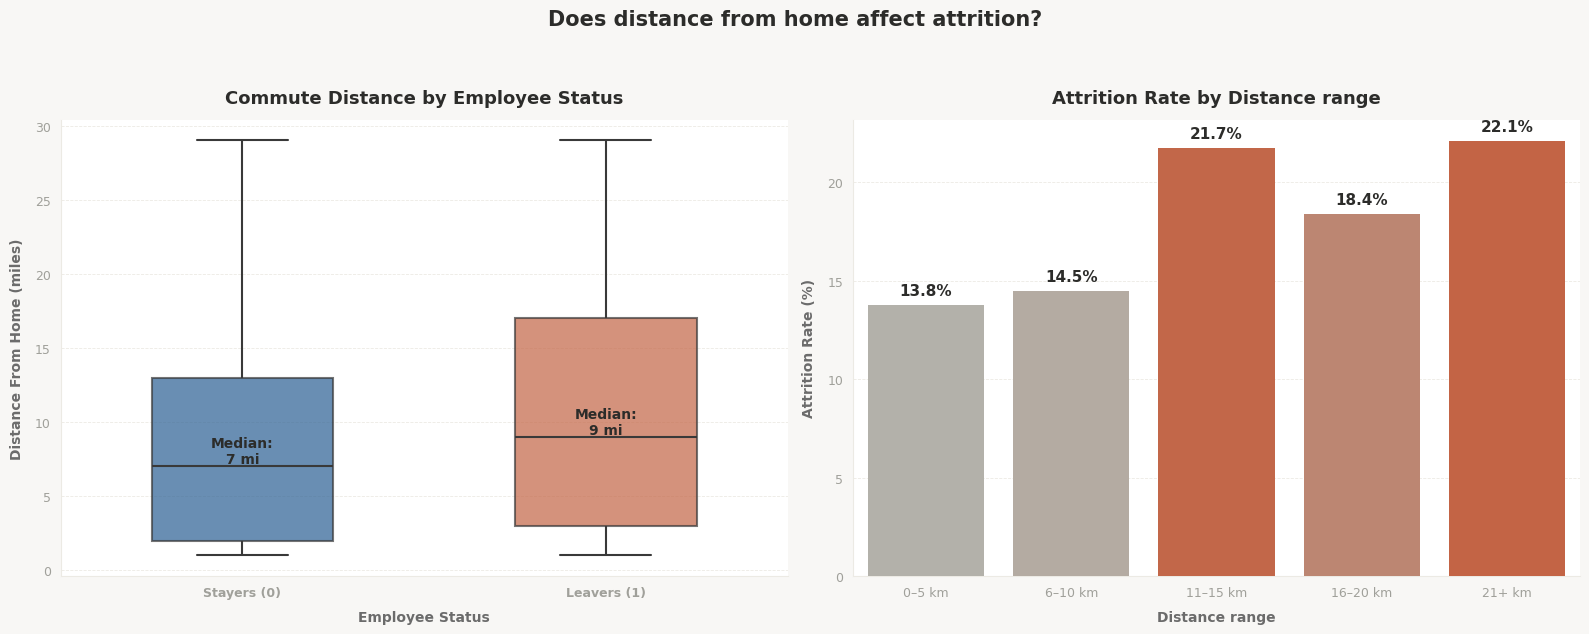

In [84]:
# Plotting the graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_PAGE)

# Box Plot
ax1.set_facecolor(BG_CARD)
attrition_colors = {0: COLOR_NEG, 1: COLOR_ACCENT}

sns.boxplot(
    data=df, 
    x='Attrition_num', 
    y='DistanceFromHome', 
    palette=attrition_colors,
    hue='Attrition_num',
    legend=False,
    width=0.5,        
    linewidth=1.5,    
    fliersize=4,      
    boxprops={'alpha': 0.7},  
    ax=ax1,
    zorder=3
)

# Add median annotations to Boxes
medians = df.groupby('Attrition_num')['DistanceFromHome'].median()
for xtick, median in medians.items():
    ax1.text(
        x=xtick, 
        y=median, 
        s=f'Median:\n{median:.0f} mi', 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        color=COLOR_TITLE,
        fontsize=10,
        fontfamily=FONT_FAMILY,
    )

ax1.set_title('Commute Distance by Employee Status', fontsize=13, fontweight='bold', color=COLOR_TITLE, pad=12, fontfamily=FONT_FAMILY)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Stayers (0)', 'Leavers (1)'], fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
ax1.set_xlabel('Employee Status', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax1.set_ylabel('Distance From Home (miles)', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax1.tick_params(colors=COLOR_MUTED, labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#ECEAE4')
ax1.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax1.set_axisbelow(True)


# The Bar Graph Plotting
ax2.set_facecolor(BG_CARD)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(dist_attrition_rate.min(), dist_attrition_rate.max())
bar_colors = [cmap(norm(value)) for value in dist_attrition_rate.values]

sns.barplot(
    x=dist_attrition_rate.index, 
    y=dist_attrition_rate.values, 
    palette=bar_colors,
    hue=dist_attrition_rate.index,
    legend=False,
    ax=ax2,
    zorder=3,
    edgecolor='none'
)

# Add percentage annotations to Bars
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY,
                xytext=(0, 5), textcoords='offset points')

ax2.set_title('Attrition Rate by Distance range', fontsize=13, fontweight='bold', color=COLOR_TITLE, pad=12, fontfamily=FONT_FAMILY)
ax2.set_xlabel('Distance range', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax2.set_ylabel('Attrition Rate (%)', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax2.tick_params(colors=COLOR_MUTED, labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#ECEAE4')
ax2.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('Does distance from home affect attrition?', 
             fontsize=15, fontweight='bold', color=COLOR_TITLE, y=1.05, fontfamily=FONT_FAMILY)

plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Employees living **21+ km away** leave at ~23% vs ~14% for those within 5 km
- Attrition rises **consistently as distance increases** — commute fatigue is a real factor
- Business implication: **flexible work or relocation support** could reduce attrition in the far-commute group
---

## 6.  Career & tenure

### 6.1. At what tenure stage do employees leave the most?

In [85]:
# Data Aggregation
bins = [0,2,5,7,10,15,20,40]
labels = ['0-2 years', '2-5 years', '5-7 years', '7-10 years', '10-15 years', '15-20 years', '20+ years']

df['tenure_range'] = pd.cut(df['YearsAtCompany'], bins = bins, labels = labels).fillna('0-2 years')

leavers_tenure = df.groupby(by = 'tenure_range',observed = True)['Attrition_num'].sum()
overall_tenure = df.groupby(by = 'tenure_range',observed = True)['Attrition_num'].count()

tenure_rate = (leavers_tenure / overall_tenure *100).round(2)
          

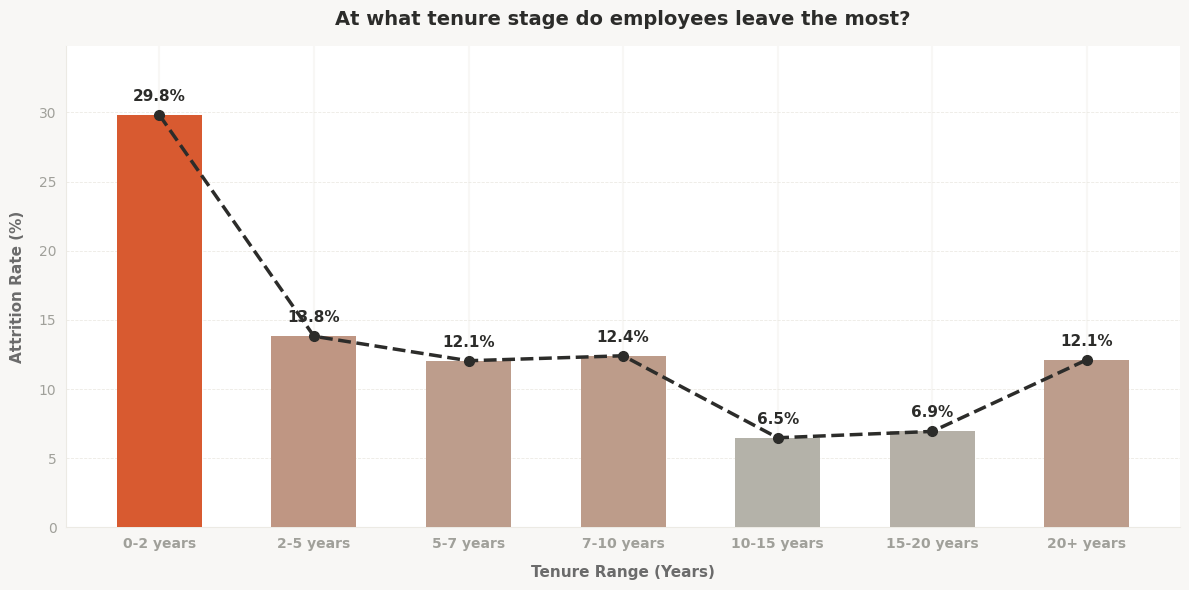

In [86]:
# Plotting the Graph
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_PAGE)
ax.set_facecolor(BG_CARD)

# Defining the custom colormap and normalizing
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(tenure_rate.min(), tenure_rate.max())
bar_colors = [cmap(norm(v)) for v in tenure_rate.values]

# Plotting the Gradient Bar Chart
x_pos = np.arange(len(tenure_rate))
bars = ax.bar(x_pos, tenure_rate.values, color=bar_colors, 
              width=0.55, zorder=3, edgecolor='none')

# Overlay the Trend Line
ax.plot(x_pos, tenure_rate.values, color=COLOR_TITLE, marker='o', 
        linewidth=2.5, markersize=7, linestyle='--', zorder=4)

# Add data labels slightly above the markers
for bar, val in zip(bars, tenure_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

# Graph Customization
ax.set_xticks(x_pos)

ax.set_xticklabels(tenure_rate.index, fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
ax.set_ylim(0, tenure_rate.max() + 5)

ax.set_title('At what tenure stage do employees leave the most?', 
             fontsize=14, fontweight='bold', color=COLOR_TITLE, pad=15, fontfamily=FONT_FAMILY)
ax.set_xlabel('Tenure Range (Years)', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')

# Clean up axes, ticks, and gridlines
ax.tick_params(colors=COLOR_MUTED, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ECEAE4')
ax.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Employees in their **first 2 years** have the highest attrition rate (~30%): the critical retention window.
- Attrition drops sharply after year 5 and remains low for long - tenured employees.
- The **retention cliff** after onboarding shows the clear early stage exploration phase of employees. 
- Employees who cross the **5 - year mark** are significantly more likely to stay long term.
---

### 6.2. Does number of previous companies affect attrition?

In [87]:
# Data Aggregation
leavers_num = df.groupby(by = 'NumCompaniesWorked', observed = True)['Attrition_num'].sum()
overall_num = df.groupby(by = 'NumCompaniesWorked', observed = True)['Attrition_num'].count()

num_rate = (leavers_num / overall_num * 100).round(2)
num_rate = num_rate.sort_index()

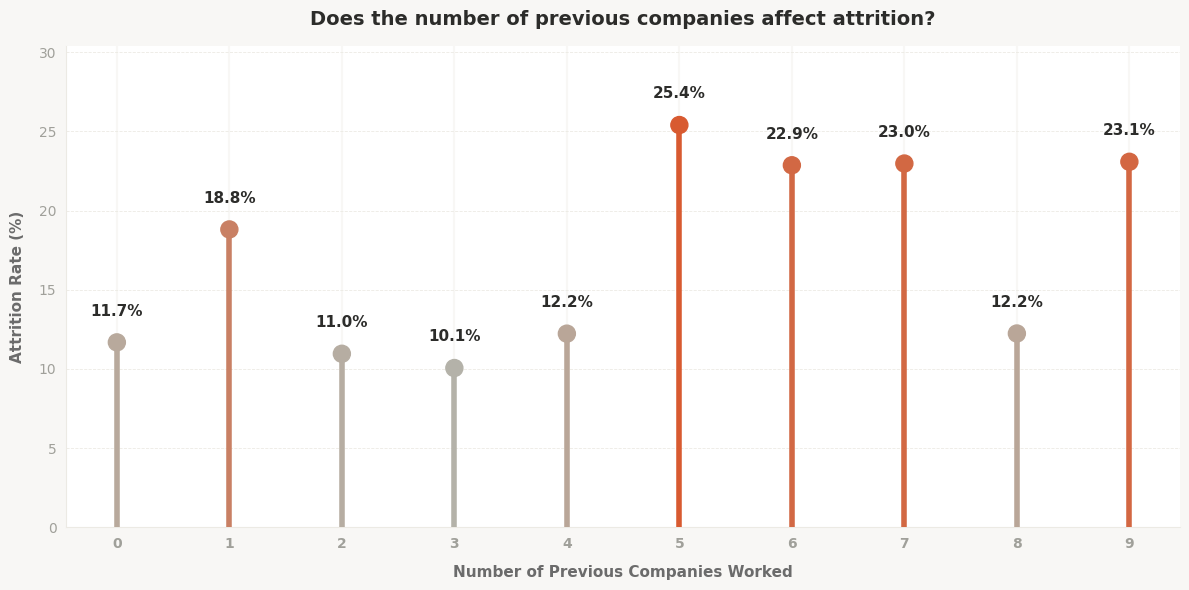

In [88]:
# Plotting the Graphs
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_PAGE)
ax.set_facecolor(BG_CARD)

# Defining the custom colormap and normalizing
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(num_rate.min(), num_rate.max())
colors = [cmap(norm(v)) for v in num_rate.values]

x_pos = np.arange(len(num_rate))

# Drawing the Stems of garph
ax.vlines(x=x_pos, ymin=0, ymax=num_rate.values, color=colors, 
          linewidth=4, zorder=3)

# Drawing the Markers
ax.scatter(x_pos, num_rate.values, color=colors, s=150, zorder=4)

# Add data labels slightly above the markers
for x, y in zip(x_pos, num_rate.values):
    ax.text(x, y + 1.5, f'{y:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

# Graph Customization
ax.set_xticks(x_pos)
ax.set_xticklabels(num_rate.index, fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
ax.set_ylim(0, num_rate.max() + 5) # Padding for labels

ax.set_title('Does the number of previous companies affect attrition?', 
             fontsize=14, fontweight='bold', color=COLOR_TITLE, pad=15, fontfamily=FONT_FAMILY)
ax.set_xlabel('Number of Previous Companies Worked', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')

# Clean up axes, ticks, and gridlines
ax.tick_params(colors=COLOR_MUTED, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ECEAE4')
ax.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Employees who have worked at **5-9 prior companies** leave at (~25%): more than double the average.
- Employees on their **first-ever job** (0 prior companies) show lower attrition: no prior habit of switching.
- **Past job-hopping is a strong predictor of future job-hopping**: a useful signal for hiring screening.
- The attrition rate rises consistently as the number of prior companies increases.
---

### 6.3. Does time since last promotion drive attrition?

In [89]:
leavers_prom = df.groupby(by = 'YearsSinceLastPromotion', observed = True)['Attrition_num'].sum()
overall_prom = df.groupby(by = 'YearsSinceLastPromotion', observed = True)['Attrition_num'].count()

lastprom_rate = (leavers_prom / overall_prom * 100).round(2)
lastprom_rate = lastprom_rate.sort_index()

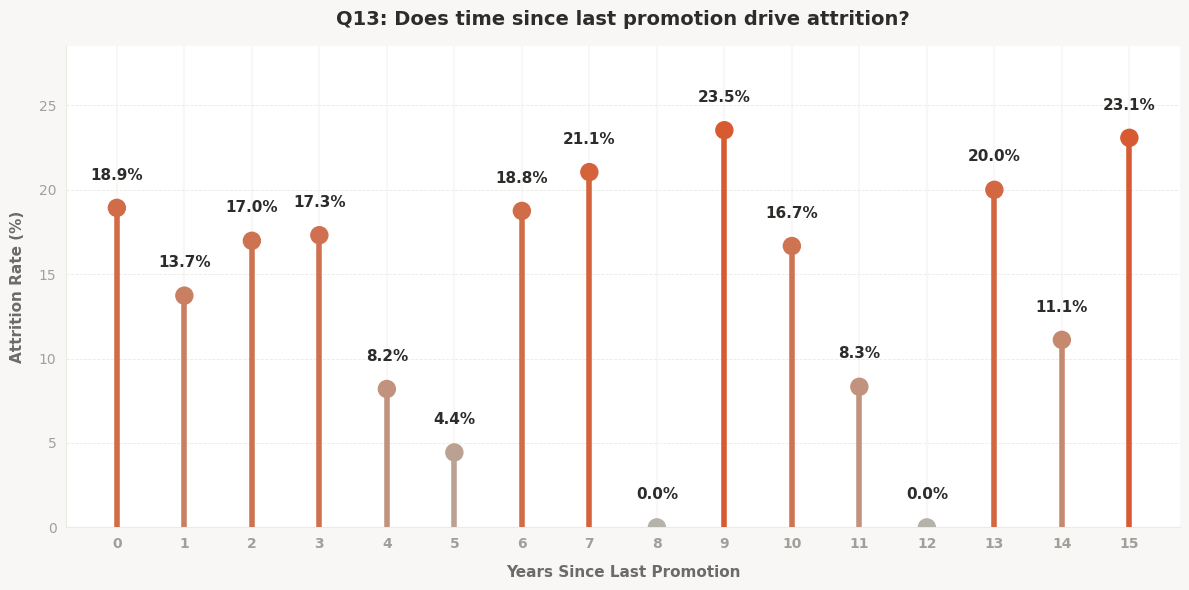

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_PAGE)
ax.set_facecolor(BG_CARD)

# Defining the custom colormap and normalizing
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])
norm = plt.Normalize(lastprom_rate.min(), lastprom_rate.max())
colors = [cmap(norm(v)) for v in lastprom_rate.values]

x_pos = np.arange(len(lastprom_rate))

# Drawing the Stems of Graphs
ax.vlines(x=x_pos, ymin=0, ymax=lastprom_rate.values, color=colors, 
          linewidth=4, zorder=3)

# Drawing the Markers
ax.scatter(x_pos, lastprom_rate.values, color=colors, s=150, zorder=4)

# Add data labels slightly above the markers
for x, y in zip(x_pos, lastprom_rate.values):
    ax.text(x, y + 1.5, f'{y:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

# Graph Customization
ax.set_xticks(x_pos)
ax.set_xticklabels(lastprom_rate.index, fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
ax.set_ylim(0, lastprom_rate.max() + 5) 

ax.set_title('Q13: Does time since last promotion drive attrition?', 
             fontsize=14, fontweight='bold', color=COLOR_TITLE, pad=15, fontfamily=FONT_FAMILY)
ax.set_xlabel('Years Since Last Promotion', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=11, color=COLOR_LABEL, labelpad=10, fontweight='bold')


ax.tick_params(colors=COLOR_MUTED, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ECEAE4')
ax.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
#### Key Insights
 
- Employees stuck without promotion for **6–7+ years** show elevated attrition: stagnation drives exits.
- **Counter-intuitive finding**: recently promoted employees (year 0–1) also show higher than average attrition.
- Likely explanation: a promotion can trigger outside offers, or the new role may not meet expectations.
- The **sweet spot for retention** is years 2–4 post-promotion: employees feel progressing but not yet stagnant.
- overall this metric is also not suitable for any decision making in this dataset.
---

### 6.4. Does education level or field affect attrition?

In [91]:
leavers_edu_level = df.groupby(by = 'Education', observed = True)['Attrition_num'].sum()
overall_edu_level = df.groupby(by = 'Education', observed = True)['Attrition_num'].count()

edu_level_rate = (leavers_edu_level / overall_edu_level * 100).round(2)
edu_level_rate = edu_level_rate.sort_index()

leavers_edu_field = df.groupby(by = 'EducationField', observed = True)['Attrition_num'].sum()
overall_edu_field = df.groupby(by = 'EducationField', observed = True)['Attrition_num'].count()

edu_field_rate = (leavers_edu_field / overall_edu_field * 100).round(2)
edu_field_rate = edu_field_rate.sort_values(ascending = False)


Education
1    18.24
2    15.60
3    17.31
4    14.57
5    10.42
Name: Attrition_num, dtype: float64

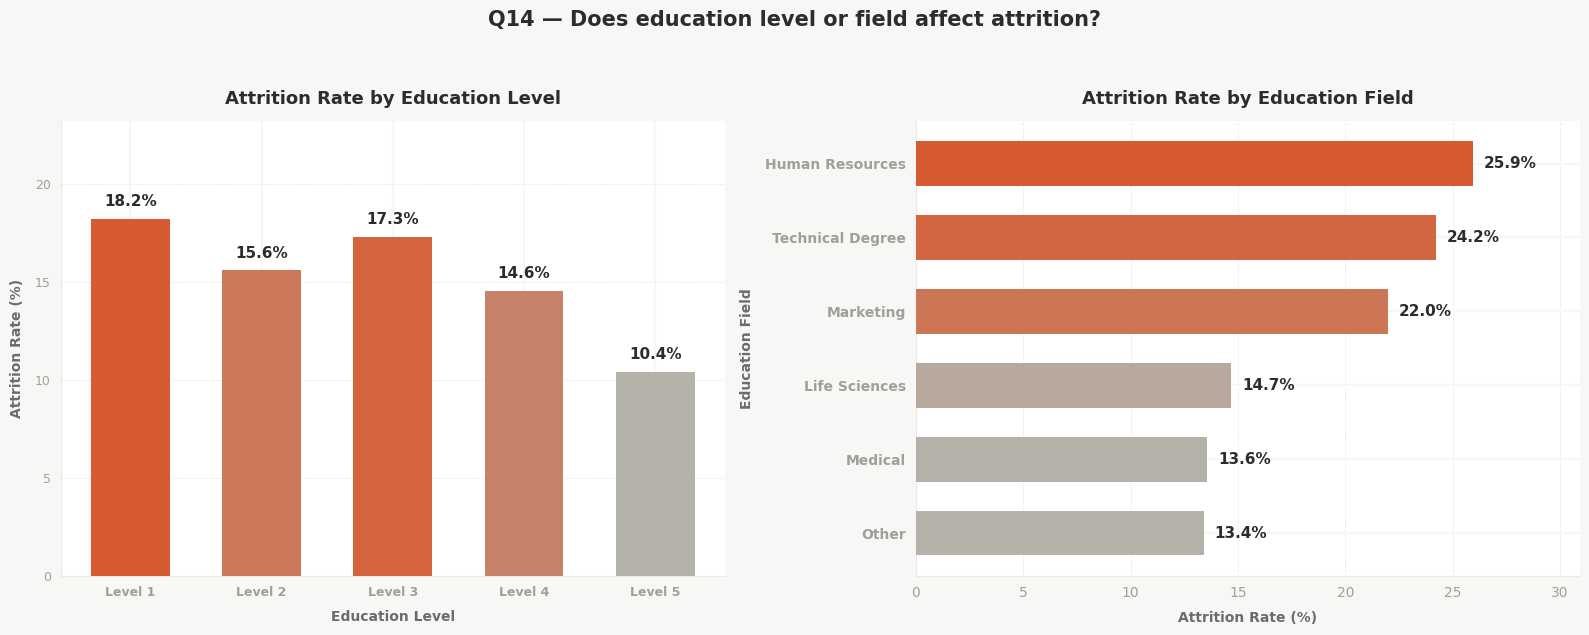

In [92]:
# Plotting the Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_PAGE)

# Defining the custom colormap used across both subplots
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [COLOR_NEUTRAL, COLOR_ACCENT])


# Creating the left plot
ax1.set_facecolor(BG_CARD)

# Normalizing gradient for Education Level
norm_level = plt.Normalize(edu_level_rate.min(), edu_level_rate.max())
colors_level = [cmap(norm_level(v)) for v in edu_level_rate.values]

# Plot vertical bars
bars1 = ax1.bar(edu_level_rate.index, edu_level_rate.values, color=colors_level, 
                width=0.6, zorder=3, edgecolor='none')

# Annotations
for bar, val in zip(bars1, edu_level_rate.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

ax1.set_xticks(edu_level_rate.index)
ax1.set_xticklabels([f'Level {i}' for i in edu_level_rate.index], fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
ax1.set_ylim(0, edu_level_rate.max() + 5)

ax1.set_title('Attrition Rate by Education Level', fontsize=13, fontweight='bold', color=COLOR_TITLE, pad=12, fontfamily=FONT_FAMILY)
ax1.set_xlabel('Education Level', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax1.set_ylabel('Attrition Rate (%)', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax1.tick_params(colors=COLOR_MUTED, labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#ECEAE4')
ax1.yaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax1.set_axisbelow(True)

# Creating the right plot
ax2.set_facecolor(BG_CARD)

# Normalizing gradient for Education Field
norm_field = plt.Normalize(edu_field_rate.min(), edu_field_rate.max())
colors_field = [cmap(norm_field(v)) for v in edu_field_rate.values]

# Plot horizontal bars
bars2 = ax2.barh(edu_field_rate.index, edu_field_rate.values, color=colors_field, 
                 height=0.6, zorder=3, edgecolor='none')

# Annotations 
for bar, val in zip(bars2, edu_field_rate.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', ha='left', va='center',
             fontsize=11, fontweight='bold', color=COLOR_TITLE, fontfamily=FONT_FAMILY)

# Graph Customizations
ax2.invert_yaxis()
ax2.set_xlim(0, edu_field_rate.max() + 5)

ax2.set_title('Attrition Rate by Education Field', fontsize=13, fontweight='bold', color=COLOR_TITLE, pad=12, fontfamily=FONT_FAMILY)
ax2.set_xlabel('Attrition Rate (%)', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax2.set_ylabel('Education Field', fontsize=10, color=COLOR_LABEL, labelpad=8)
ax2.tick_params(colors=COLOR_MUTED, labelsize=10)

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontfamily(FONT_FAMILY)

ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#ECEAE4')

ax2.xaxis.grid(True, color='#ECEAE4', linewidth=0.6, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('Does education level or field affect attrition?', 
             fontsize=15, fontweight='bold', color=COLOR_TITLE, y=1.05, fontfamily=FONT_FAMILY)

plt.tight_layout()
plt.show()

---
#### Key Insights — Q14: Education level and field and attrition
 
- **Below College(level 1)** educated employees have the highest attrition by education level.
- Attrition generally **decreases as education level increases**: higher qualifications correlate with stability & better offers.
- By field, **Human Resources and Technical Degree** holders show the highest attrition rates.
- **Life Sciences and Medical** graduates have the lowest attrition: likely due to specialized, stable roles.
- Technical Degree holders likely leave for **better-paying tech roles**: a field-specific retention challenge.
---

# Conclusion & Key Takeaways
 ---
### Top findings:
 
- **Overtime is the #1 driver**: employees doing overtime leave at 30.5% vs 10.4% a 3x risk multiplier.
- **Low income compounds the risk**: leavers earn ~$1,716/month less than stayers on average.
- **Early tenure is also the vulnerable window**: 30% of employees leave within their first 2 years.
- **Low job satisfaction is critical**: Employees with satisfaction score of 1 leave at 46%, nearly 3x the company average.
- **Sales Representatives are the most at-risk role** at ~40% attrition: nearly double the company average.
- **Long commutes erode retention**: employees living 21+ km away leave at 23% vs 12% for nearby.
 
### Business recommendations:
 
- **Cap overtime** in the Sales department: strongest single lever to reduce attrition.
- **Salary band review** for entry level and Lab Technician roles underpayment is a consistent signal.
- **Structured onboarding program** for the first 2 years: Programs can be done to retain freshers.
- **Flexible work policy** for employees living 20+ km away: commute fatigue is measurable and solvable.
- **Promotion cadence review**: employees stagnant for 6+ years without promotion are actively disengaging.
 
### Limitations:
 
- Dataset is a **static snapshot**: no time-series data to track actual monthly attrition trends.
- Attrition rate calculated as `leavers / total headcount` which is not the standard HR formula due to dataset constraints.
 ---